In [4]:
from google.colab import files

print("Please select and upload 'historical_data.csv' and 'fear_greed_index.csv':")
uploaded = files.upload()

Please select and upload 'historical_data.csv' and 'fear_greed_index.csv':


Saving fear_greed_index.csv to fear_greed_index.csv
Saving historical_data.csv to historical_data.csv


In [5]:
import pandas as pd

trader_data = pd.read_csv('historical_data.csv')
sentiment_data = pd.read_csv('fear_greed_index.csv')

print("Trader Data Loaded. Shape:", trader_data.shape)
print("Sentiment Data Loaded. Shape:", sentiment_data.shape)

Trader Data Loaded. Shape: (211224, 16)
Sentiment Data Loaded. Shape: (2644, 4)


Compilation Successful! Total matching rows found: 211218

classification  average_pnl  average_trade_size  total_executed_trades
  Extreme Fear    34.537862         5349.731843                  21400
 Extreme Greed    67.892861         3112.251565                  39992
          Fear    54.290400         7816.109931                  61837
         Greed    42.743559         5736.884375                  50303
       Neutral    34.307718         4782.732661                  37686


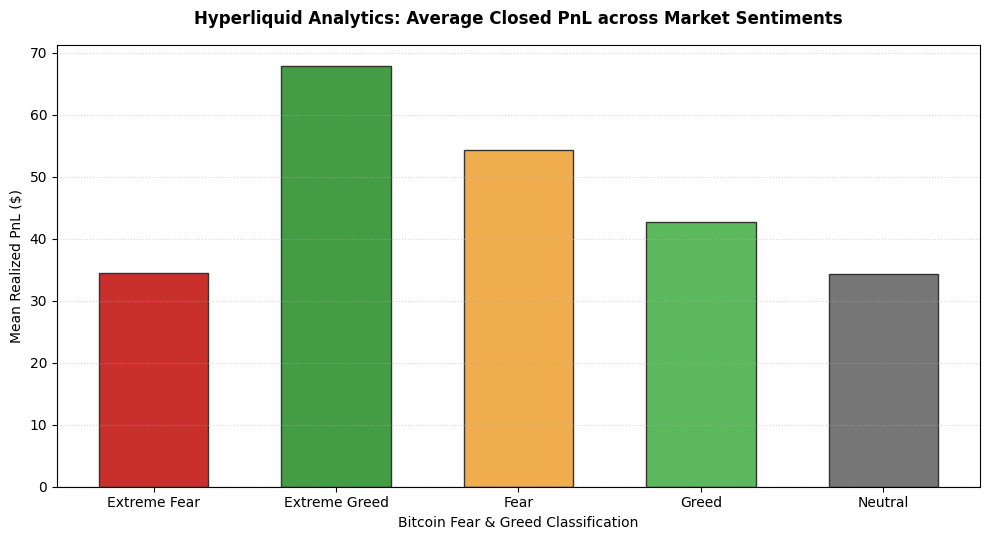

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

def load_and_clean_trading_data():
    # Load files
    trades = pd.read_csv('historical_data.csv')
    sentiment = pd.read_csv('fear_greed_index.csv')

    # Clean workspace: columns ke aage peeche ke hidden spaces hatane ke liye
    trades.columns = trades.columns.str.strip()
    sentiment.columns = sentiment.columns.str.strip()

    # Date formatting (Dono files ke date format alag hain, isko align kiya)
    trades['Join_Date'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.strftime('%Y-%m-%d')
    sentiment['Join_Date'] = pd.to_datetime(sentiment['date']).dt.strftime('%Y-%m-%d')

    # Perfect inner merge using the synchronized date string
    master_df = pd.merge(trades, sentiment, on='Join_Date', how='inner')
    return master_df

def process_sentiment_insights(df):
    # Numeric cleanup: Kuch values strings ho sakti hain, unhe float banaya
    df['Closed PnL'] = pd.to_numeric(df['Closed PnL'], errors='coerce')
    df['Size USD'] = pd.to_numeric(df['Size USD'], errors='coerce')

    # Performance aggregation by market sentiment
    summary = df.groupby('classification').agg(
        average_pnl=('Closed PnL', 'mean'),
        average_trade_size=('Size USD', 'mean'),
        total_executed_trades=('Closed PnL', 'count')
    ).reset_index()

    return summary

def plot_trader_behavior(summary_df):
    plt.figure(figsize=(10, 5.5))

    # Premium hex palette for dashboard styling
    sentiment_colors = {
        'Extreme Fear': '#c9302c',
        'Fear': '#f0ad4e',
        'Neutral': '#777777',
        'Greed': '#5cb85c',
        'Extreme Greed': '#449d44'
    }

    colors = [sentiment_colors.get(x, '#31708f') for x in summary_df['classification']]

    plt.bar(summary_df['classification'], summary_df['average_pnl'], color=colors, edgecolor='#333333', width=0.6)

    plt.title('Hyperliquid Analytics: Average Closed PnL across Market Sentiments', fontsize=12, fontweight='bold', pad=15)
    plt.xlabel('Bitcoin Fear & Greed Classification', fontsize=10)
    plt.ylabel('Mean Realized PnL ($)', fontsize=10)

    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    try:
        combined_data = load_and_clean_trading_data()
        print(f"Compilation Successful! Total matching rows found: {len(combined_data)}\n")

        if len(combined_data) > 0:
            final_metrics = process_sentiment_insights(combined_data)
            print(final_metrics.to_string(index=False))
            plot_trader_behavior(final_metrics)
        else:
            print("Check failed: Row match count is still 0. Double-check file uploads.")
    except Exception as error_msg:
        print(f"Execution stopped due to: {error_msg}")